# **Подгоовка** данных по территории

## 1. Получение кварталов

### 1.1. Получение данных из **OpenStreetMap**. 
Этот шаг можно пропустить, если данные уже существуют.

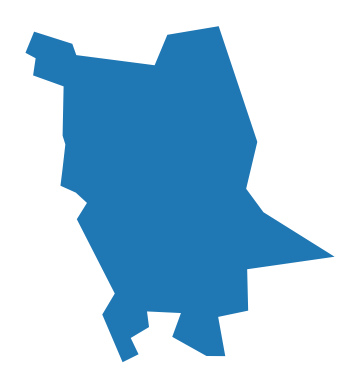

In [1]:
import osmnx as ox

boundaries = ox.geocode_to_gdf('Сватово, Сватовская городская община')
boundaries.plot().set_axis_off()

In [2]:
bc_tags = {
    'roads': {
      "highway": ["construction","crossing","living_street","motorway","motorway_link","motorway_junction","pedestrian","primary","primary_link","raceway","residential","road","secondary","secondary_link","services","tertiary","tertiary_link","track","trunk","trunk_link","turning_circle","turning_loop","unclassified",],
      "service": ["living_street", "emergency_access"]
    },
    'railways': {
      "railway": "rail"
    },
    'water': {
      'riverbank':True,
      'reservoir':True,
      'basin':True,
      'dock':True,
      'canal':True,
      'pond':True,
      'natural':['water','bay'],
      'waterway':['river','canal','ditch'],
      'landuse':'basin',
      'water': 'lake'
    }
}

In [3]:
water = ox.features_from_polygon(boundaries.union_all(), bc_tags['water'])
roads = ox.features_from_polygon(boundaries.union_all(), bc_tags['roads'])
railways = ox.features_from_polygon(boundaries.union_all(), bc_tags['railways'])

In [4]:
water = water[water.geom_type.isin(['Polygon', 'MultiPolygon', 'LineString', 'MultiLineString'])].copy()
roads = roads[roads.geom_type.isin(['LineString', 'MultiLineString'])].copy()
railways = railways[railways.geom_type.isin(['LineString', 'MultiLineString'])].copy()

In [5]:
crs = boundaries.estimate_utm_crs()

for gdf in [water, roads, railways, boundaries]:
  gdf.to_crs(crs, inplace=True)

### 1.2. Предварительная обработка входной геометрии

Этот шаг можно пропустить, если входная геометрия уже отсортирована как линии, многоугольники и границы.

In [6]:
roads = roads.reset_index(drop=True)
railways = railways.reset_index(drop=True)
water = water.reset_index(drop=True)

In [7]:
from blocksnet.blocks.cutting import preprocess_urban_objects, cut_urban_blocks

lines, polygons = preprocess_urban_objects(roads, railways, water)

2025-12-10 13:42:49.597 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:44 - Checking roads schema
2025-12-10 13:42:49.602 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:51 - Checking railways schema
2025-12-10 13:42:49.606 | INFO     | blocksnet.blocks.cutting.preprocessing.core:preprocess_urban_objects:58 - Checking water schema


### 1.3. **Нарезка** городских кварталов

2025-12-10 13:42:49.615 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:51 - Checking boundaries schema
2025-12-10 13:42:49.619 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:55 - Checking line objects schema
2025-12-10 13:42:49.626 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:62 - Checking polygon objects schema
2025-12-10 13:42:49.630 | INFO     | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:69 - Checking buildings schema
2025-12-10 13:42:49.631 | WARNING  | blocksnet.blocks.cutting.processing.schemas:validate_and_preprocess_gdfs:71 - Creating empty buildings
2025-12-10 13:42:49.652 | SUCCESS  | blocksnet.blocks.cutting.processing.core:cut_urban_blocks:26 - 157 blocks are successfully cut


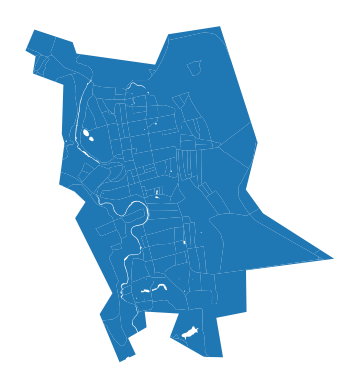

In [8]:
blocks = cut_urban_blocks(boundaries, lines, polygons)
blocks.plot().set_axis_off()

___


## 2. Назначение **землепользования**


### 2.1. Получение данных из OpenStreetMap

Этот шаг можно пропустить, если слой функциональных зон уже получен из государственных источников.

In [9]:
import osmnx as ox

functional_zones = ox.features_from_polygon(boundaries.to_crs(4326).union_all(), tags={'landuse': True})

In [10]:
functional_zones = functional_zones.reset_index(drop=True)[['geometry','landuse']].rename(columns={'landuse': 'functional_zone'})
functional_zones = functional_zones.to_crs(crs)
functional_zones.head()

,geometry,functional_zone
0,"POLYGON ((440935.821 5472820.764, 440926.523 5...",forest
1,"POLYGON ((436141.427 5474925.165, 436167.2 547...",forest
2,"POLYGON ((436262.318 5476188.359, 436284.951 5...",forest
3,"POLYGON ((436708.022 5472986.797, 436753.541 5...",forest
4,"POLYGON ((436553.288 5473604.049, 436608.313 5...",cemetery



### 2.2. Указание правил

Правила определяют, как столбец `functional_zone` будет отображаться в `LandUse`.

In [11]:
from blocksnet.enums import LandUse

rules = {
  'commercial': LandUse.BUSINESS,
  'industrial': LandUse.INDUSTRIAL,
  'cemetery': LandUse.SPECIAL,
  'garages': LandUse.INDUSTRIAL,
  'residential': LandUse.RESIDENTIAL,
  'retail': LandUse.BUSINESS,
  'grass': LandUse.RECREATION,
  'farmland': LandUse.AGRICULTURE,
  'construction': LandUse.SPECIAL,
  'brownfield': LandUse.INDUSTRIAL,
  'forest': LandUse.RECREATION,
  'recreation_ground': LandUse.RECREATION,
  'religious': LandUse.SPECIAL,
  'flowerbed': LandUse.RECREATION,
  'military': LandUse.SPECIAL,
  'landfill': LandUse.TRANSPORT
}

### 2.3. Назначение земплепользования 

In [12]:
from blocksnet.blocks.assignment import assign_land_use

blocks = assign_land_use(blocks, functional_zones.reset_index(drop=True).rename(columns={'landuse': 'functional_zone'}), rules)

2025-12-10 13:42:49.789 | WARNING  | blocksnet.blocks.assignment.land_use:_preprocess_functional_zones:17 - Functional zones not in rules: reservoir, meadow, farmyard, orchard


In [13]:
blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623
1,"POLYGON ((442745.301 5471695.335, 442718.951 5...",0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288
2,"POLYGON ((442580.521 5471789.381, 442718.951 5...",0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516
3,"POLYGON ((442505.529 5471832.217, 442580.521 5...",0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953
4,"POLYGON ((442505.529 5471832.217, 442243.731 5...",0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280


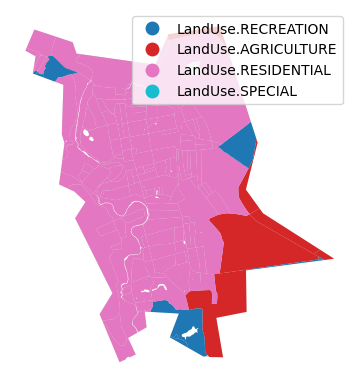

In [14]:
ax = blocks.plot(color='#ddd')
blocks.plot(column='land_use', legend=True, ax=ax).set_axis_off()

___

# **Urbanomy**

In [15]:
from urbanomy.methods.land_value_modeling.land_data_preparation import LandDataPreparator

preparator = LandDataPreparator(
    scenario_blocks_source=blocks,
    context_blocks_source=False,
    predict_project_only=False, 
)

prepared_blocks = preparator.prepare()
prepared_blocks.head()

/Users/mvin/Code/Urbanomy/src/urbanomy/methods/land_value_modeling/land_data_preparation.py:187: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  blocks = pd.concat([scenario, context], ignore_index=True)
2025-12-10 13:42:50.750 | WARNING  | blocksnet.analysis.morphotypes.schemas:_before_validate:17 - Column l not found in columns. Calculating from fsi and gsi


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id
0,0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,0.000000,...,1.531440e+04,0.003101,0.000000,0.0,inf,high-rise non-residential,52.955679,False,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0
1,0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,0.000000,...,5.550162e+04,0.000000,0.000000,0.0,0.000000,NaN,54.646338,False,"POLYGON ((442745.301 5471695.335, 442718.951 5...",1
2,0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,32.598434,...,4.129025e+03,0.000000,0.007895,0.0,0.000000,NaN,54.333506,False,"POLYGON ((442580.521 5471789.381, 442718.951 5...",2
3,0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,29328.609995,...,2.146705e+06,0.088668,0.013662,0.0,6.490026,mid-rise non-residential,38.950568,False,"POLYGON ((442505.529 5471832.217, 442580.521 5...",3
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,0.000000,...,3.875414e+05,0.000000,0.000000,0.0,0.000000,NaN,42.734392,False,"POLYGON ((442505.529 5471832.217, 442243.731 5...",4


In [16]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=prepared_blocks,
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,is_project,geometry,id,land_value
0,0.0,0.0,0.394623,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.394623,0.000000,...,0.003101,0.000000,0.0,inf,high-rise non-residential,52.955679,False,"POLYGON ((442718.951 5471710.302, 442745.301 5...",0,1.449316e+07
1,0.0,0.0,0.039570,0.00000,0.0,0.0,0.906288,LandUse.AGRICULTURE,0.906288,0.000000,...,0.000000,0.000000,0.0,0.000000,NaN,54.646338,False,"POLYGON ((442745.301 5471695.335, 442718.951 5...",1,4.543772e+07
2,0.0,0.0,0.297516,0.00000,0.0,0.0,0.000000,LandUse.RECREATION,0.297516,32.598434,...,0.000000,0.007895,0.0,0.000000,NaN,54.333506,False,"POLYGON ((442580.521 5471789.381, 442718.951 5...",2,4.451464e+06
3,0.0,0.0,0.040294,0.09687,0.0,0.0,0.492953,LandUse.AGRICULTURE,0.492953,29328.609995,...,0.088668,0.013662,0.0,6.490026,mid-rise non-residential,38.950568,False,"POLYGON ((442505.529 5471832.217, 442580.521 5...",3,1.644742e+09
4,0.0,0.0,0.000000,0.00000,0.0,0.0,0.906280,LandUse.AGRICULTURE,0.906280,0.000000,...,0.000000,0.000000,0.0,0.000000,NaN,42.734392,False,"POLYGON ((442505.529 5471832.217, 442243.731 5...",4,4.190746e+08


count       155.000000
mean     268327.697086
std      105742.680609
min       34851.177787
25%      185750.428706
50%      282784.110532
75%      350418.578881
max      490748.630757
Name: price_per_sotka, dtype: float64


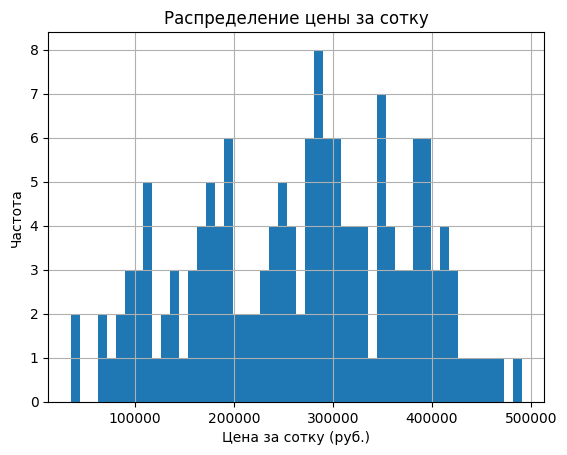

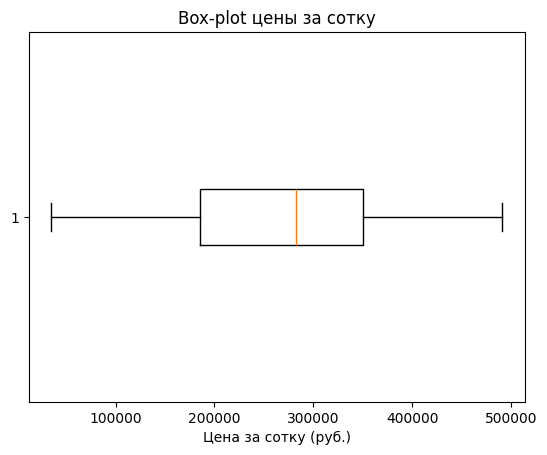

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


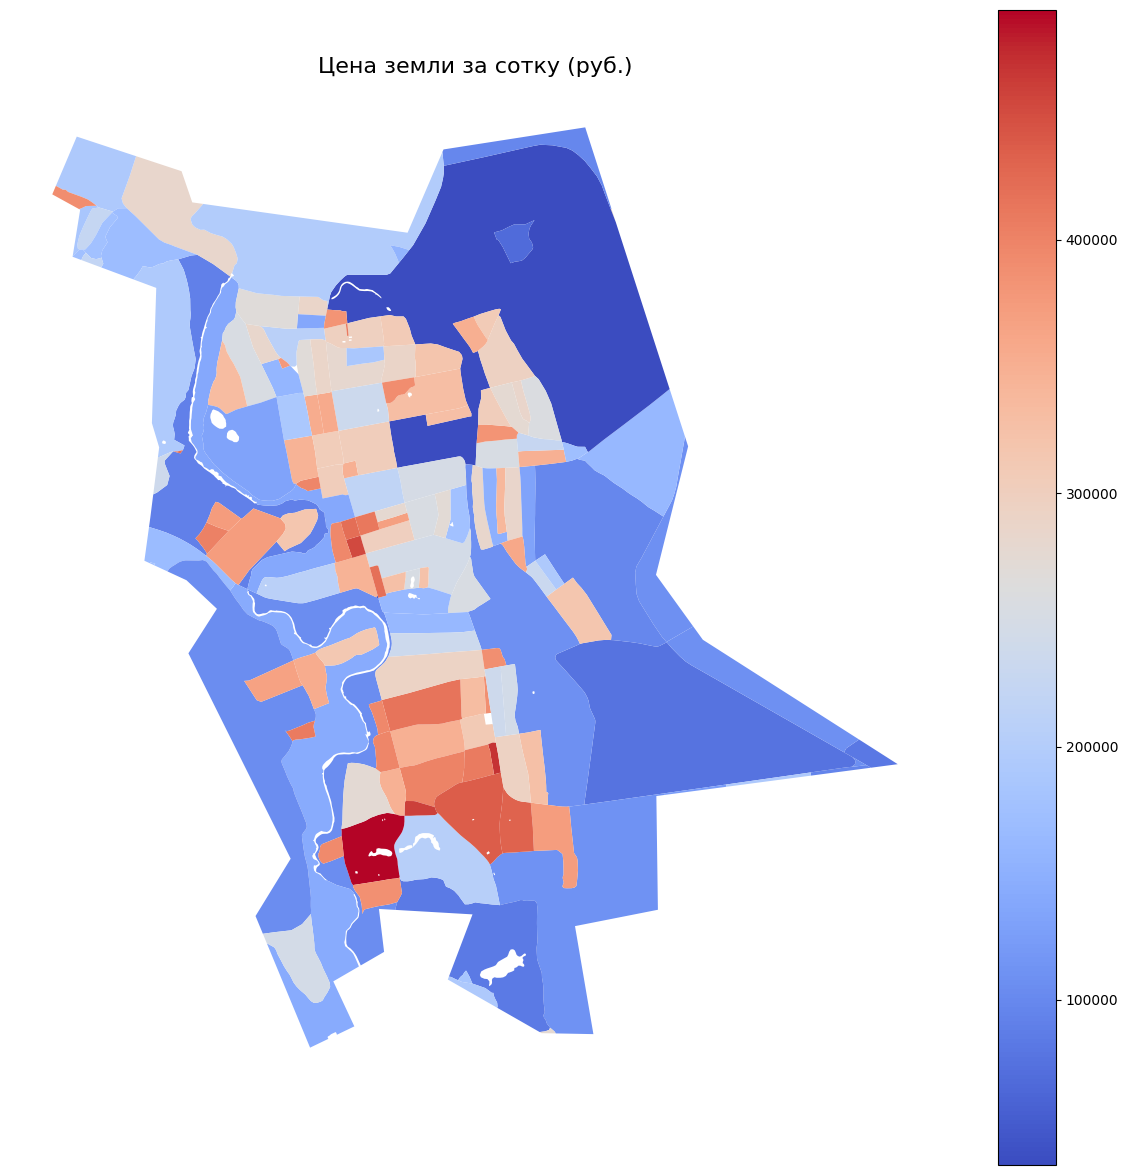

In [19]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цена земли за сотку (руб.)', fontsize=16)

plt.show()

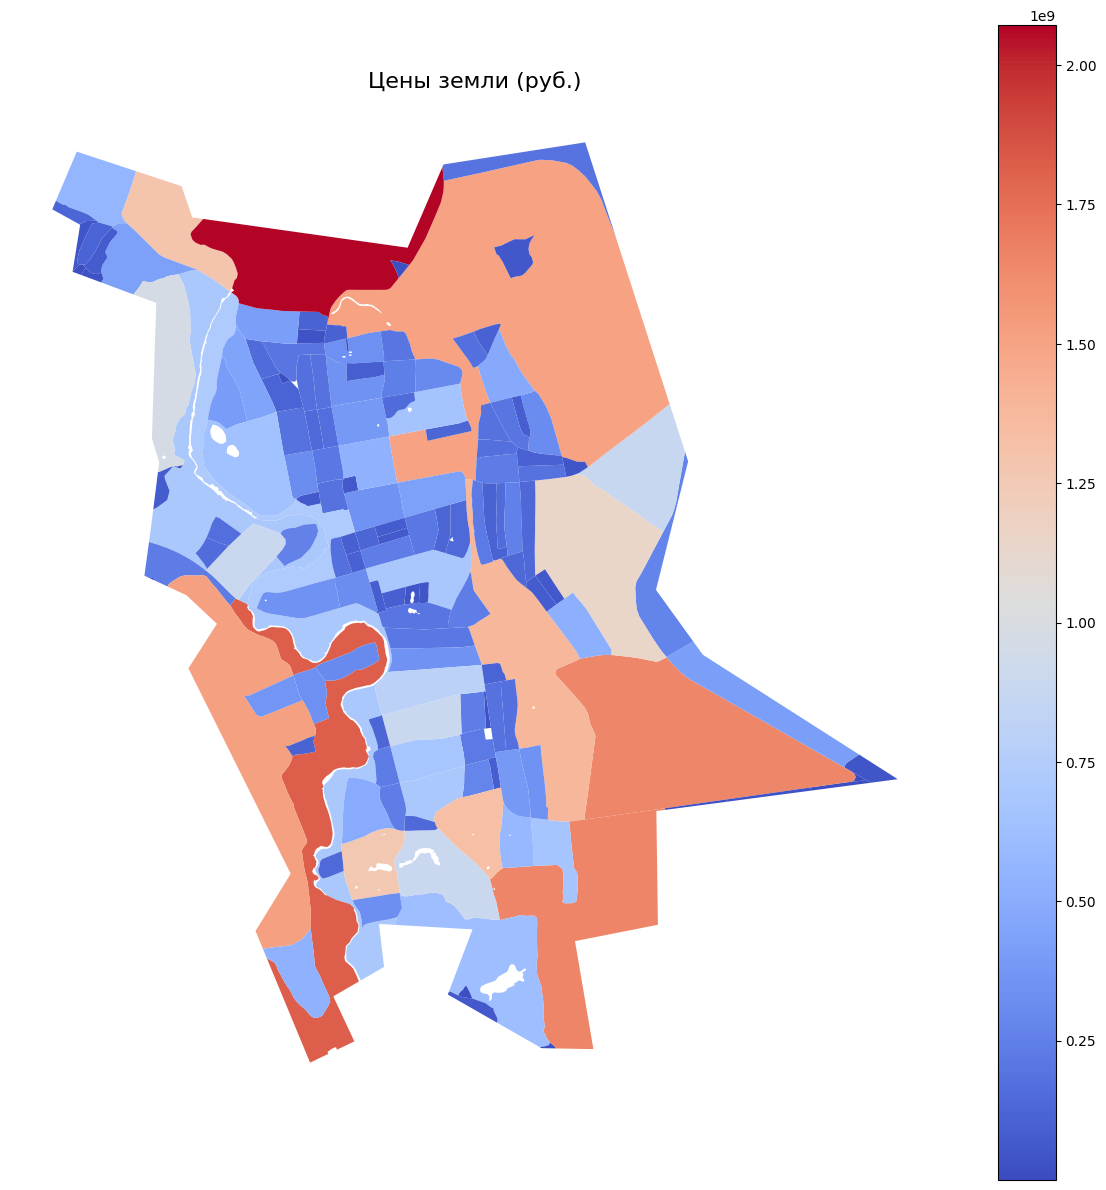

In [20]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='coolwarm'
).set_axis_off()
plt.title('Цены земли (руб.)', fontsize=16)

plt.show()

In [21]:
blocks_clean.explore()

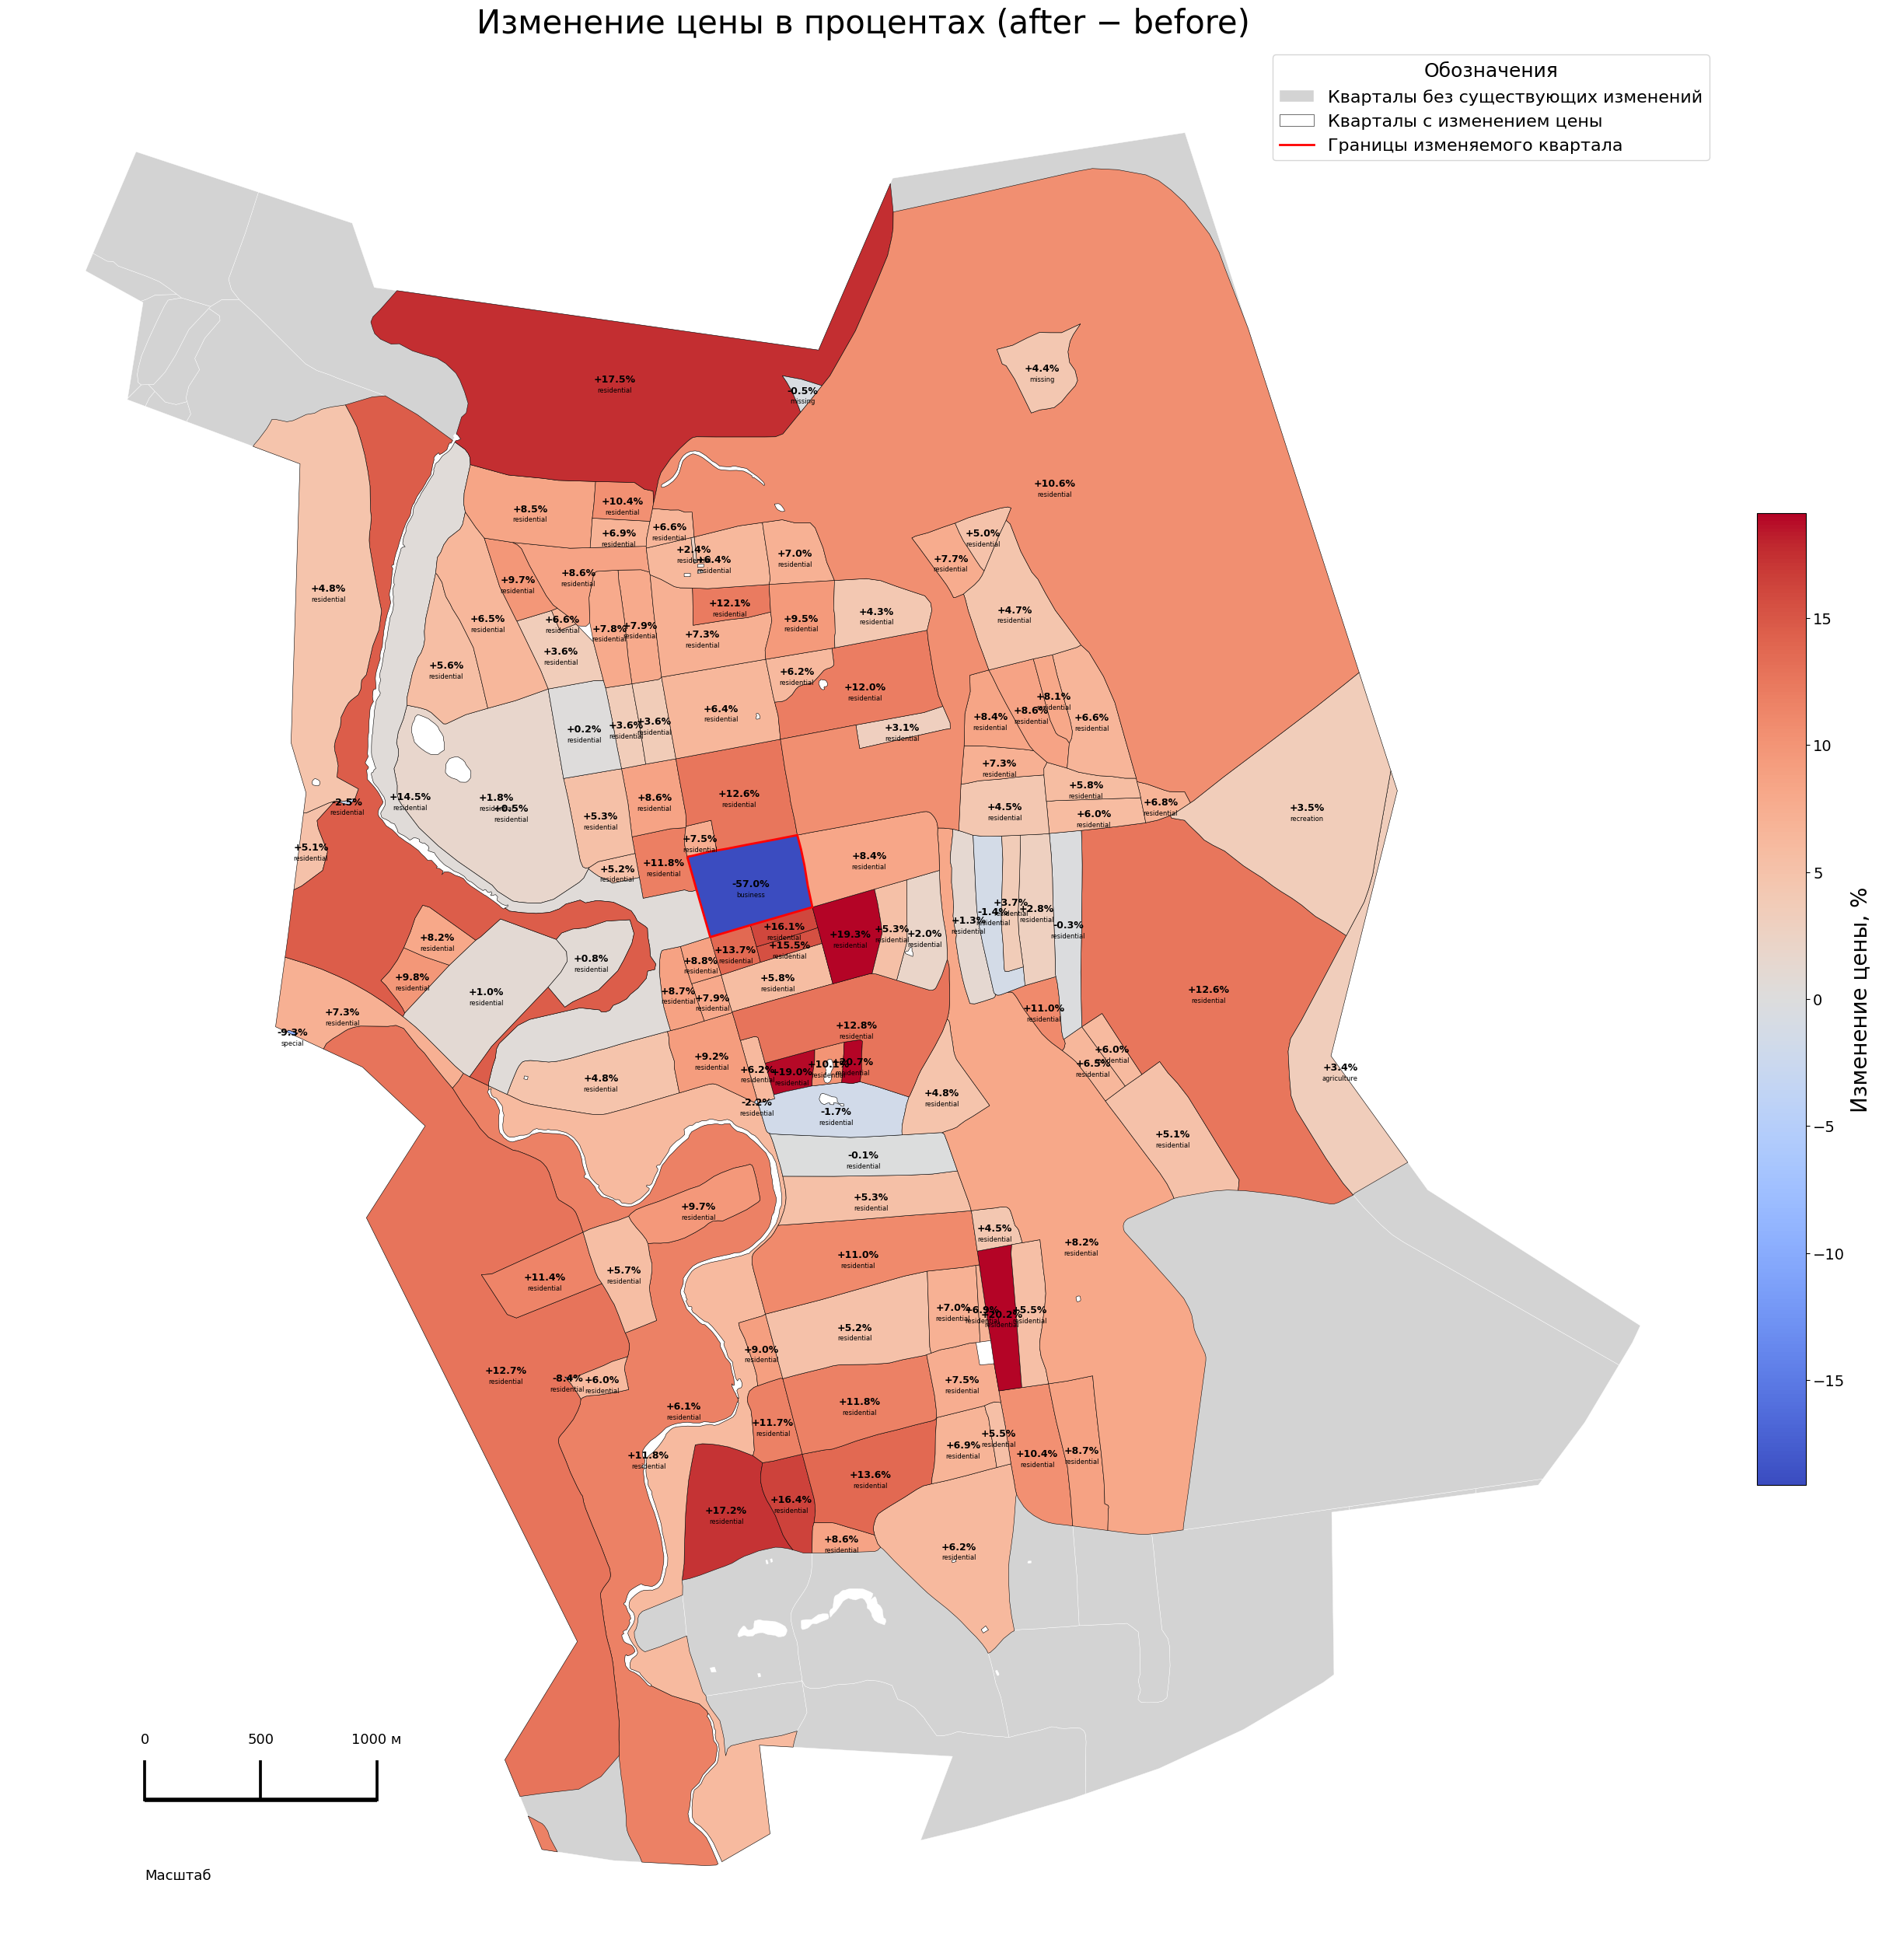


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
16 | business | 344 287 065 ₽ → 148 084 272 ₽ | -196 202 793 ₽ | -57.0%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
34 | residential | 1 809 052 613 ₽ → 2 022 424 312 ₽ | +213 371 698 ₽ | +11.8%
96 | residential | 1 517 382 953 ₽ → 1 710 519 280 ₽ | +193 136 327 ₽ | +12.7%
111 | residential | 60 449 ₽ → 55 369 ₽ | -5 080 ₽ | -8.4%
110 | residential | 109 104 202 ₽ → 115 700 341 ₽ | +6 596 140 ₽ | +6.0%
149 | residential | 358 161 808 ₽ → 399 108 349 ₽ | +40 946 541 ₽ | +11.4%
87 | residential | 350 977 783 ₽ → 367 875 400 ₽ | +16 897 617 ₽ | +4.8%
150 | special | 932 107 ₽ → 845 484 ₽ | -86 623 ₽ | -9.3%
36 | residential | 231 938 587 ₽ → 248 884 224 ₽ | +16 945 637 ₽ | +7.3%
35 | residential | 893 533 228 ₽ → 902 036 522 ₽ | +8 503 294 ₽ | +1.0%
120 | residenti

In [22]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение
    'land_use': 'LandUse.BUSINESS',
    'residential': 0.0,
    'business': 1.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,

    # Морфология и площади
    'footprint_area': 20_000.0,
    'build_floor_area': 40_000.0,
    'living_area': 0.0,
    'non_living_area': 30_000.0,

    # Плотности (обновляем по формулам)
    'fsi': 0.7942,
    'gsi': 0.0529,
    'mxi': 0.0,

    # Население
    'population': 0.0,

    # Морфотип
    'morphotype': 'high-rise non-residential',
}
target_idx = 16

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 40),
)

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_21344/1999342981.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  blocks_after.loc[blocks_after["is_project"]].plot(
/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_21344/1999342981.py:8: UserWarning: The GeoSeries you are attempting to plot is empty. Nothing has been displayed.
  blocks_after.loc[blocks_after["is_project"]].centroid.plot(


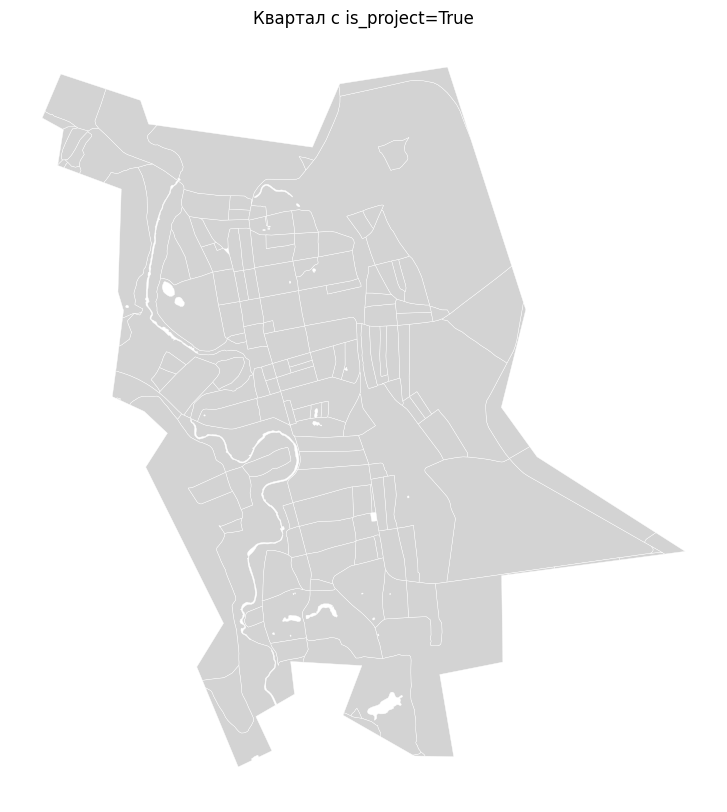

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
blocks_after.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.3)  # фон
blocks_after.loc[blocks_after["is_project"]].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=2.5
)
blocks_after.loc[blocks_after["is_project"]].centroid.plot(
    ax=ax, color="red", markersize=30, zorder=3
)

ax.set_title("Квартал с is_project=True")
ax.axis("off")
plt.show()

# **Инвестиционная** привлекактельтность 

In [24]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True
manual_land_value_before = 148084272
blocks_after.at[target_idx, "land_value_before"] = manual_land_value_before

In [25]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [26]:
from urbanomy.methods.investment_potential import prepare_investment_input
import pandas as pd

potential_df = pd.read_csv("./data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.BUSINESS,3.472495e+08,148084272.0,159911.214374,0.0,30000.0,40000.0,1.0,4.0


In [31]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          159,911.21
 • Built area:         30,000.00
 • Land value:         347,249,455.69
 • Construction cost:  1,650,000,000.00
 • Investment need:    1,997,249,455.69
 • Spatial potential:  4.00
 • Project NPV:        417,566,552.39
 • Project IRR:        0.22
 • Project ROI:        9.60
 • Project PP (yrs):   11.06
 • Project EI:         65.85
 • Project INV score:  38.57


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.BUSINESS,159911.21,148084272.0,30000.0,3.472495e+08,1.650000e+09,1.997249e+09,4.175666e+08,0.22,9.6,11.06,65.85,4.0,46.09


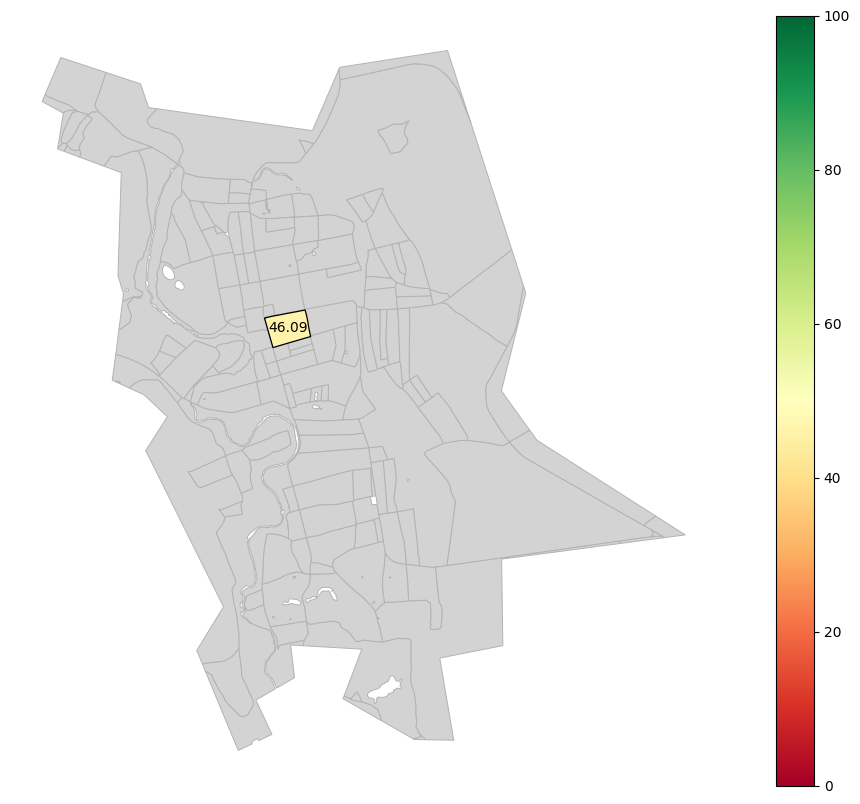

In [32]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "INV"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(15, 10))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [29]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,5 500
1,Валовый региональный продукт на душу населения,3 950
2,Доходы бюджета территории,923 878 478
3,Средний уровень заработной платы,129
4,Износ основного фонда (тыс. руб.),47 025
